In [1]:
## Imports from 1_clean_merge_data.ipynb
import pandas as pd
import numpy as np
import re
import requests
import yaml
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import curve_fit
import time

## Set font parameters early
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

headers = {
    'User-Agent': 'EskildsenLogan research project (logan.j.eskildsen.28@dartmouth.edu)'
}

## Repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [28]:
## Load relevant search trend data for visualization
regional_final_df = pd.read_csv('../data/regional_final_data.csv')

In [34]:
regional_final_sum_df = regional_final_df.groupby(['country', 'date'])[['cultural_interest_1', 'cultural_interest_2',
                                                                       'match_interest_1', 'match_interest_2']].sum().reset_index()

regional_final_sum_df['cultural_interest'] = regional_final_sum_df['cultural_interest_1'] + regional_final_sum_df['cultural_interest_2']
regional_final_sum_df['match_interest'] = regional_final_sum_df['match_interest_1'] + regional_final_sum_df['match_interest_2']

regional_final_sum_df['date']

regional_final_sum_df['date'] = pd.to_datetime(regional_final_sum_df['date'].astype(str), format='%Y-%m-%d')

regional_final_sum_df

0     2026-05-17
1     2026-05-24
2     2026-05-31
3     2026-06-07
4     2026-06-14
         ...    
70    2026-07-26
71    2026-08-02
72    2026-08-09
73    2026-08-16
74    2026-08-23
Name: date, Length: 75, dtype: object

,country,date,cultural_interest_1,cultural_interest_2,match_interest_1,match_interest_2,cultural_interest,match_interest
0,Australia,2026-05-17,4,0,5,0,4,5
1,Australia,2026-05-24,31,0,22,0,31,22
2,Australia,2026-05-31,43,0,49,23,43,72
3,Australia,2026-06-07,53,1,102,5,54,107
4,Australia,2026-06-14,63,5,1049,117,68,1166
...,...,...,...,...,...,...,...,...
70,Turkey,2026-07-26,0,0,1,0,0,1
71,Turkey,2026-08-02,1,0,4,0,1,4
72,Turkey,2026-08-09,0,1,0,2,1,2
73,Turkey,2026-08-16,0,0,1,0,0,1


Text(0.5, 1.0, 'Australia')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Proportional Weekly Interest (log)')

Text(0.5, 1.0, 'Belgium')

Text(0.5, 0, 'Date')

...

Text(0, 0.5, 'Proportional Weekly Interest (log)')

Text(0.5, 1.0, 'Turkey')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Proportional Weekly Interest (log)')

Text(0.5, 1.01, 'Match versus Cultural Search Interest Over Time, All U.S. Host Cities')

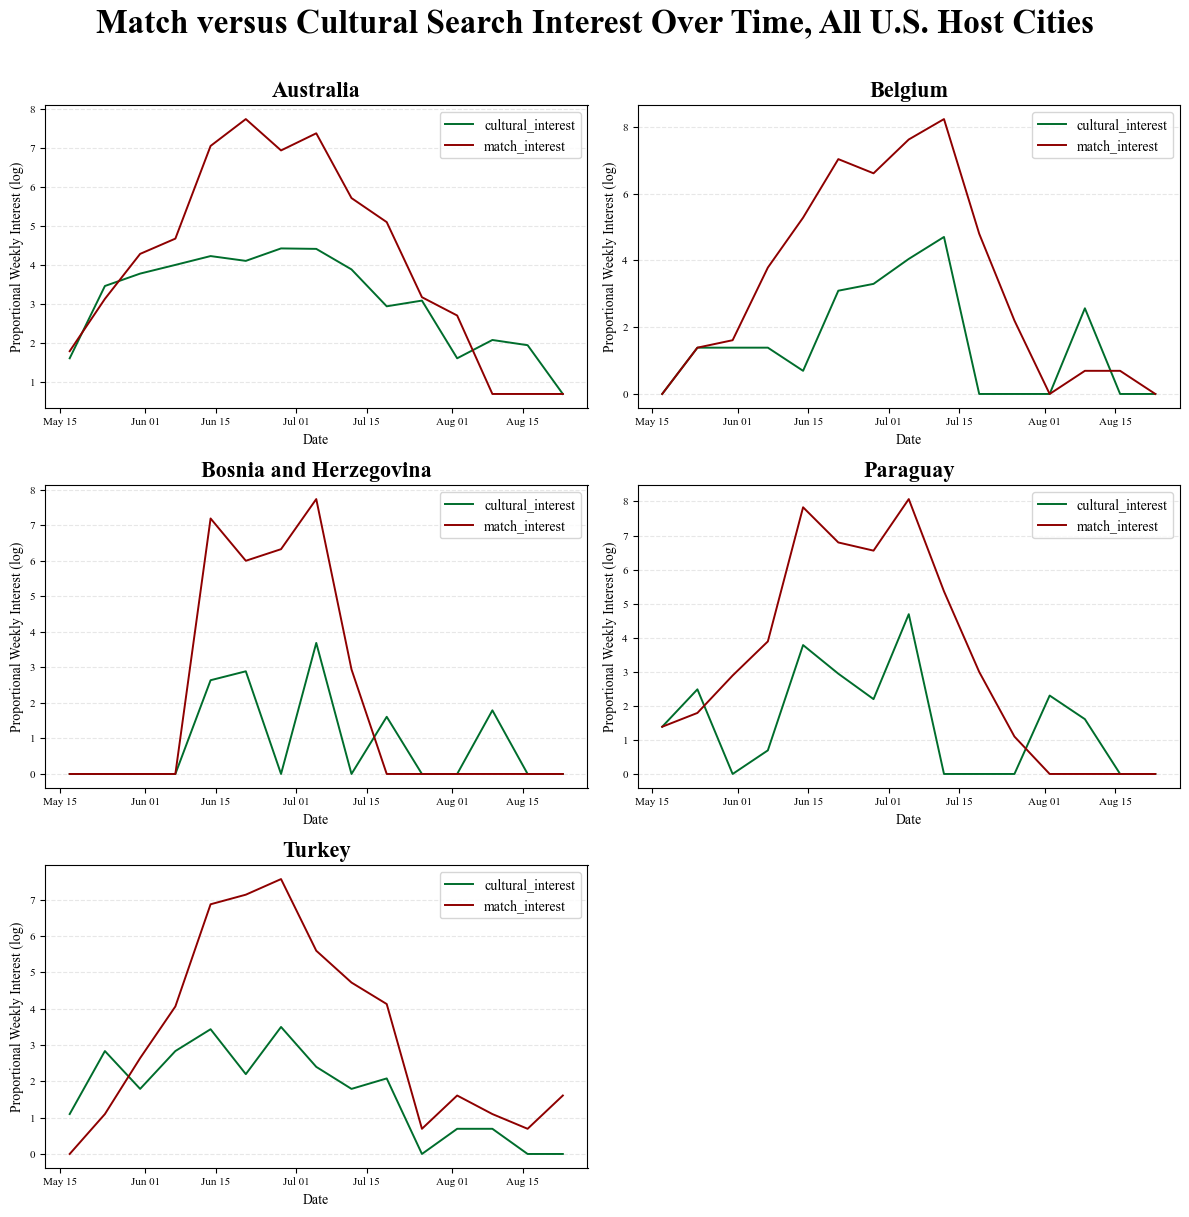

In [39]:
categories = ['cultural_interest', 'match_interest']
countries = regional_final_sum_df['country'].unique()

colors = {'cultural_interest': '#006D2C', 'match_interest': '#8e0000'}

fig, axes = plt.subplots(3,2, figsize=(12,12), sharex=False, sharey=False)
axes = axes.flatten()

for ax, country in zip(axes, countries):
    split_country = regional_final_sum_df[regional_final_sum_df['country'] == country].sort_values('date')

    for cat in categories:
        ax.plot(split_country['date'], np.log1p(split_country[cat]), label = cat, linewidth = 1.4, color=colors[cat])

    ax.set_title(country.replace('_', ' '), fontsize=16, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.legend(fontsize=10)
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Proportional Weekly Interest (log)', fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

for i in range(5, len(axes)):
    fig.delaxes(axes[i])

fig.suptitle("Match versus Cultural Search Interest Over Time, All U.S. Host Cities", fontsize=24, fontweight='bold', y = 1.01)
plt.tight_layout()
plt.savefig('../outputs/figure_4.png', dpi=300, bbox_inches='tight')
plt.show()

